In [1]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['axes.grid'] = False

2026-02-11 08:36:59.414278: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-11 08:36:59.414981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-11 08:36:59.557096: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-11 08:37:00.836672: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

# Preprocessing & Feature engineering

In [2]:
df = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month_day.csv')
df = df.drop(columns=['unique_entry_per_day', 'total_admittances'])
first_value = df['total_encounters'].iloc[0]
df['detrended_te'] = df['total_encounters'].diff(1)
display(df.dropna(inplace=True))
date_time = pd.to_datetime(df.pop('Date'), format='%Y-%m-%d')


None

#### FFT to encode clock

array([<Axes: >, <Axes: >], dtype=object)

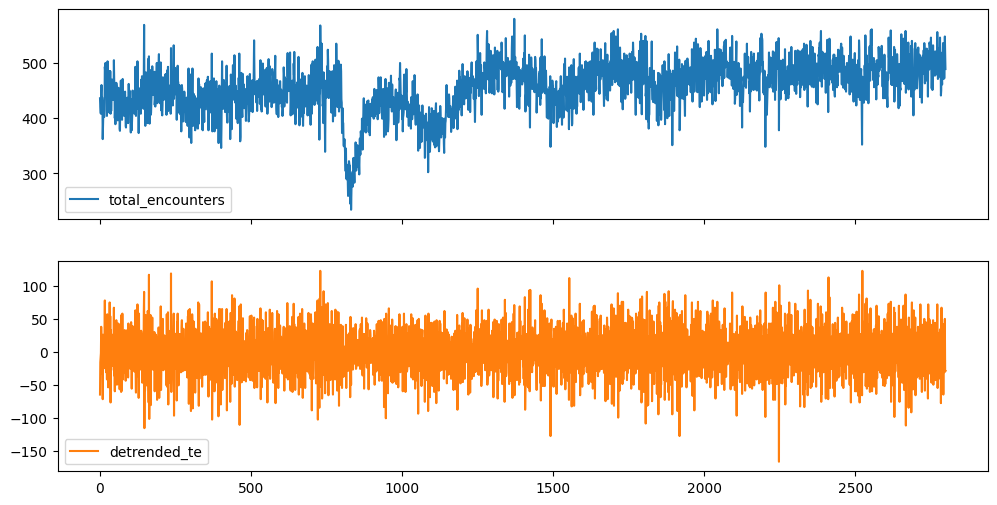

In [3]:
timestamp_s = date_time.map(pd.Timestamp.timestamp) # we convert to seconds
df.plot(subplots=True)


2026-02-11 08:37:01.435116: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


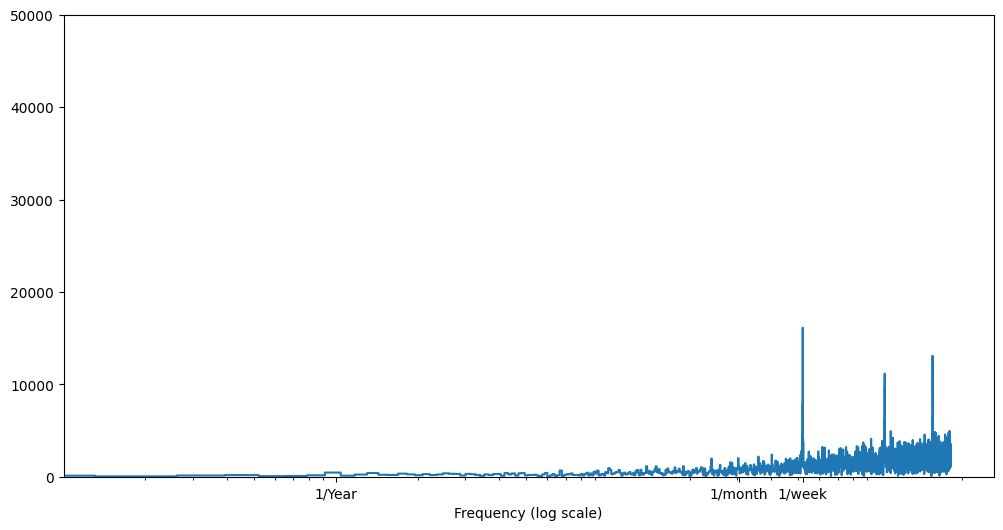

In [4]:
fft = tf.signal.rfft(df['detrended_te'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['detrended_te'])
days_per_year = 365.2524
years_per_dataset = n_samples_h/(days_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 50000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524/12, 365.2524/7], labels=['1/Year', '1/month', '1/week'])
_ = plt.xlabel('Frequency (log scale)')

In [5]:
day = 24 * 60 * 60
week = 7 * day
year = 365.2425 * day

# first week harmonic 
df['week_sin_1'] = np.sin(2 * np.pi * timestamp_s / week)
df['week_cos_1'] = np.cos(2 * np.pi * timestamp_s / week)
# second week harmonic
df['week_sin_2'] = np.sin(2 * np.pi * 2 * timestamp_s / week)
df['week_cos_2'] = np.cos(2 * np.pi * 2 * timestamp_s / week)
# third week harmonic
df['week_sin_3'] = np.sin(2 * np.pi * 3 * timestamp_s / week)
df['week_cos_3'] = np.cos(2 * np.pi * 3 * timestamp_s / week)

In [6]:
df = df.drop('detrended_te', axis=1)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

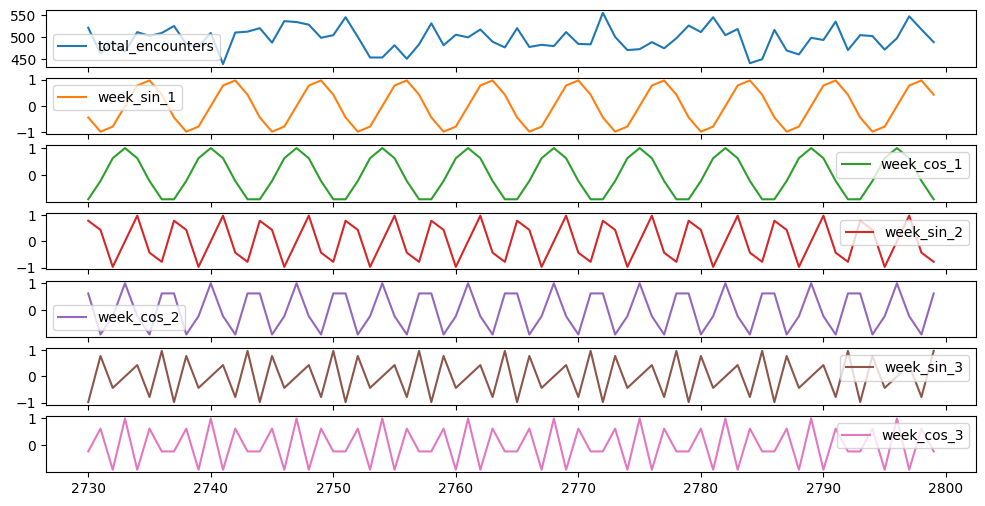

In [7]:
df[-70:].plot(subplots=True)

#### Split Data

In [8]:
column_indices = {name: i for i, name in enumerate(df.columns)}
num_features = df.shape[1]

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

#### Normalize z-score

In [9]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

# Env Variables

In [10]:
# Env variables

BATCH_SIZE = 64

MAX_EPOCHS = 100
LR = 7e-4

LOOK_BACK = 28
OUT_STEPS = 7

# CNN
CONV_WIDTH = 14

# AR-LSTM
UNITS = 32



# Window Generator class

In [11]:
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None, batch_size=BATCH_SIZE):
        
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.batch_size = batch_size

        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_ids = {name: i for i, name in 
                                      enumerate(label_columns)}
        
        self.column_ids = {name: i for i, name in
                           enumerate(train_df.columns)}
        
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        # Work out input ids
        self.input_slice = slice(0, input_width)
        self.input_ids = np.arange(self.total_window_size)[self.input_slice]

        # Work out label ids
        self.labels_start = self.total_window_size - label_width
        self.label_slice = slice(self.labels_start, None)
        self.label_ids = np.arange(self.total_window_size)[self.label_slice]



    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_ids}',
            f'Label indices: {self.label_ids}',
            f'Label column name(s): {self.label_columns}'])
    
    def split_window(self, features):
        # features.shape = (batch_size, time, features)
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.label_slice, :]

        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_ids[name]] for name in self.label_columns],
                axis=-1
            )

        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels
    
    def plot(self, model=None, plot_col='total_encounters', max_subplots=4):
        inputs, labels = self.example
        plt.figure(figsize=(12, 20))
        plot_col_index = self.column_ids[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.plot(self.input_ids, inputs[n, :, plot_col_index],
                    label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_ids.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_ids, labels[n, :, label_col_index],
                        edgecolors='k', label='Labels', c='#2ca02c', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_ids, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions',
                            c='#ff7f0e', s=64)

            if n == 0:
                plt.legend()

        plt.xlabel('Time [h]')

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=self.batch_size
        )
        
        # do the split (inputs, labels) -> inputs, labels
        ds = ds.map(self.split_window)
        return ds
    
    @property
    def train(self):
        return self.make_dataset(self.train_df)
    
    @property
    def val(self):
        return self.make_dataset(self.val_df)
    
    @property
    def test(self):
        return self.make_dataset(self.test_df)
    
    @property
    def example(self):
        result = getattr(self, '_example', None)
        if result is None:
            result = next(iter(self.train))
            self._example = result
        return result


# Models

In [12]:
# Helper function 
def compile_and_fit(model, window, patience=3, max_epochs = MAX_EPOCHS, lr=LR):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-9),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=max_epochs,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

Total window size: 35
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27]
Label indices: [28 29 30 31 32 33 34]
Label column name(s): None

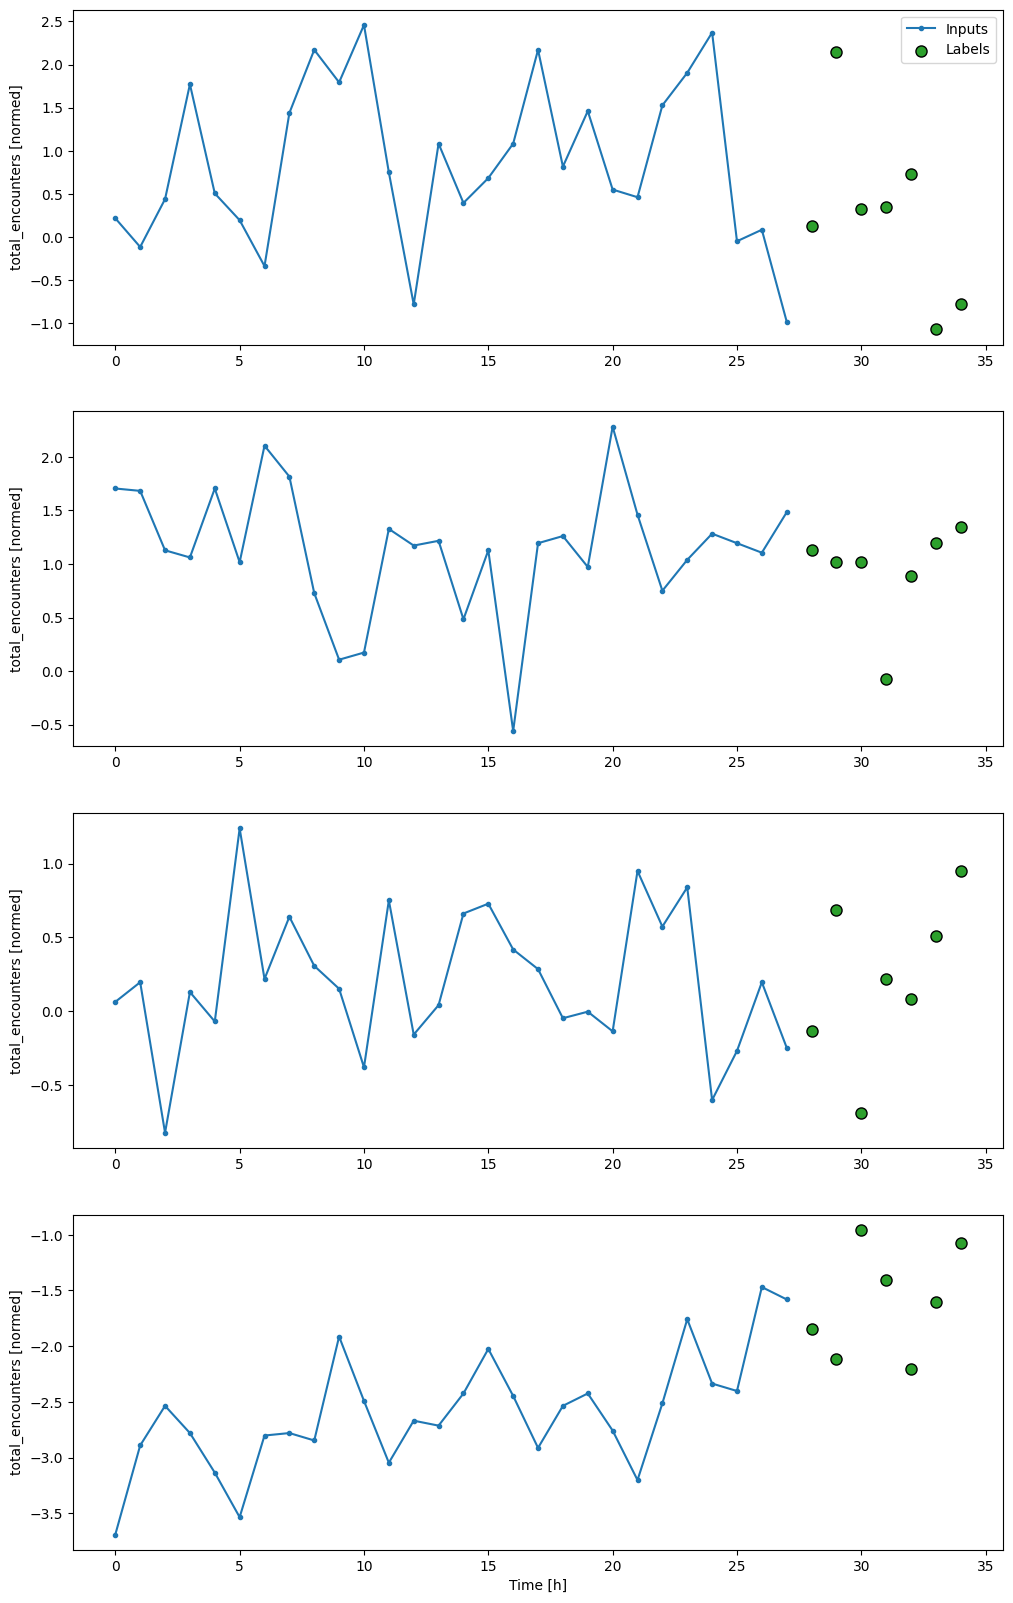

In [13]:
multi_window = WindowGenerator(input_width=LOOK_BACK,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               batch_size=BATCH_SIZE
                               )

multi_window.plot()
multi_window

In [14]:
multi_val_performance = {}
multi_performance = {}

#### CNN

##### CNN 1

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8249 - mean_absolute_error: 0.7881 - val_loss: 0.5526 - val_mean_absolute_error: 0.6292
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2623 - mean_absolute_error: 0.3532 - val_loss: 0.1568 - val_mean_absolute_error: 0.1963
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1003 - mean_absolute_error: 0.1374 - val_loss: 0.1009 - val_mean_absolute_error: 0.1424
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0730 - mean_absolute_error: 0.1081 - val_loss: 0.0751 - val_mean_absolute_error: 0.1238
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0652 - mean_absolute_error: 0.1017 - val_loss: 0.0664 - val_mean_absolute_error: 0.1122
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0640 - mean_absolute_error: 0.0981 - val_loss: 0.0647 - val_mean_absolute_error: 0.1062
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0632 - mean_absolute_error: 0.0951 - val_loss

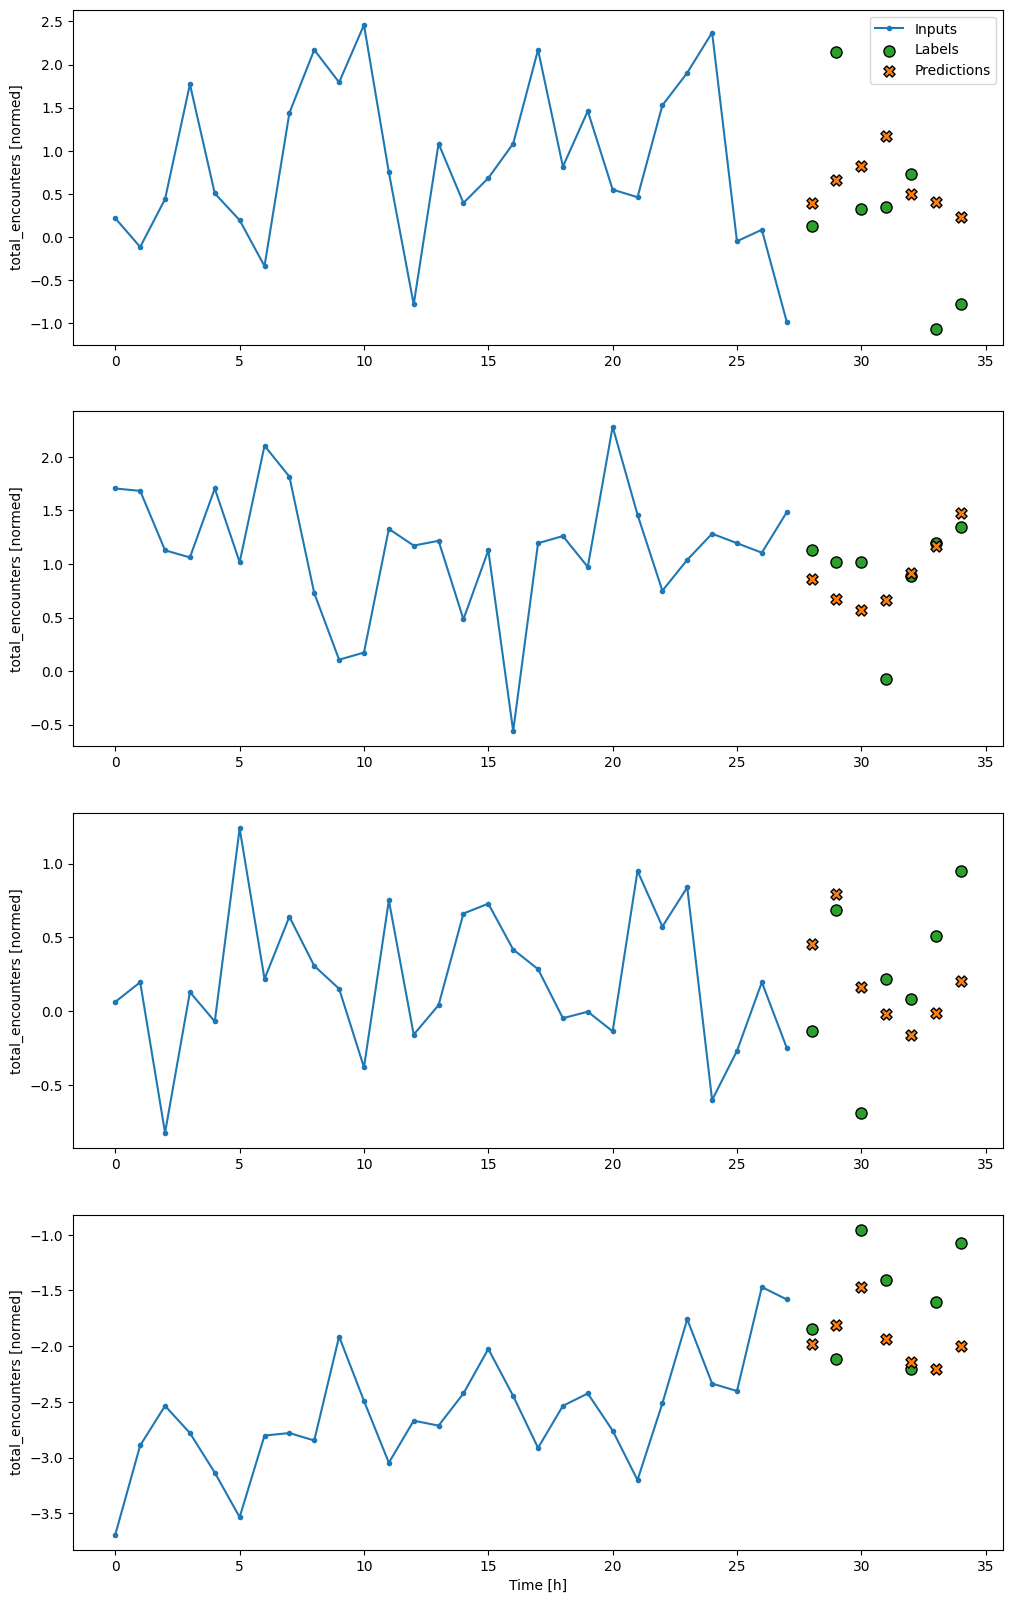

In [15]:
multi_conv_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, CONV_WIDTH, features]
    tf.keras.layers.Lambda(lambda x: x[:, -CONV_WIDTH:, :]),
    # Shape => [batch, 1, conv_units]
    tf.keras.layers.Conv1D(64, activation='relu', kernel_size=(CONV_WIDTH)),
    # Shape => [batch, 1,  out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_conv_model, multi_window, lr=LR)

# IPython.display.clear_output()
multi_val_performance['Conv'] = multi_conv_model.evaluate(multi_window.val, verbose=0, return_dict=True)
multi_performance['Conv'] = multi_conv_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_conv_model)

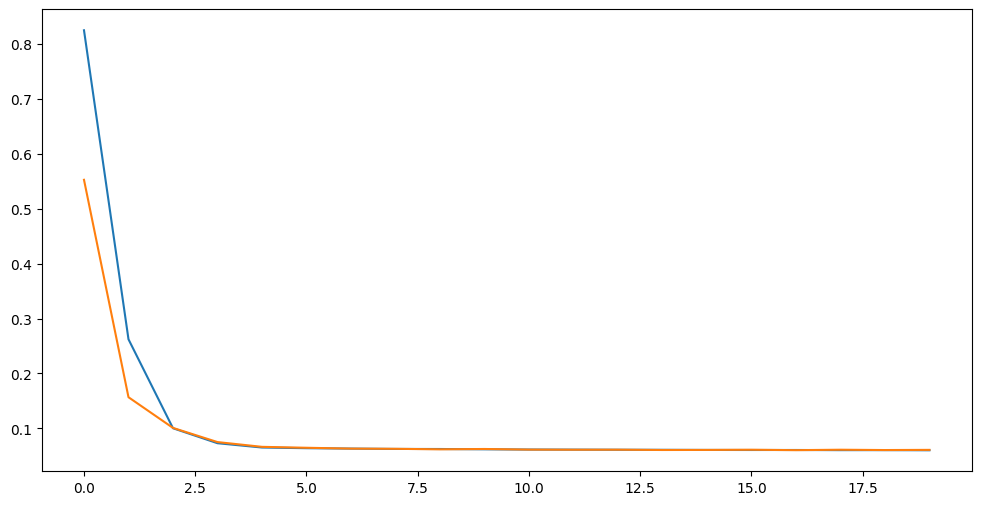

In [16]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']

plt.plot(train_losses)
plt.plot(val_losses)

plt.show()

##### CNN 2

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8875 - mean_absolute_error: 0.8291 - val_loss: 0.7584 - val_mean_absolute_error: 0.7683
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5569 - mean_absolute_error: 0.6458 - val_loss: 0.2543 - val_mean_absolute_error: 0.4254
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1253 - mean_absolute_error: 0.2322 - val_loss: 0.0685 - val_mean_absolute_error: 0.1393
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0707 - mean_absolute_error: 0.1159 - val_loss: 0.0611 - val_mean_absolute_error: 0.1020
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0672 - mean_absolute_error: 0.0966 - val_loss: 0.0605 - val_mean_absolute_error: 0.0912
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0663 - mean_absolute_error: 0.0920 - val_loss: 0.0609 - val_mean_absolute_error: 0.0891
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0652 - mean_absolute_error: 0.0902 - val_loss

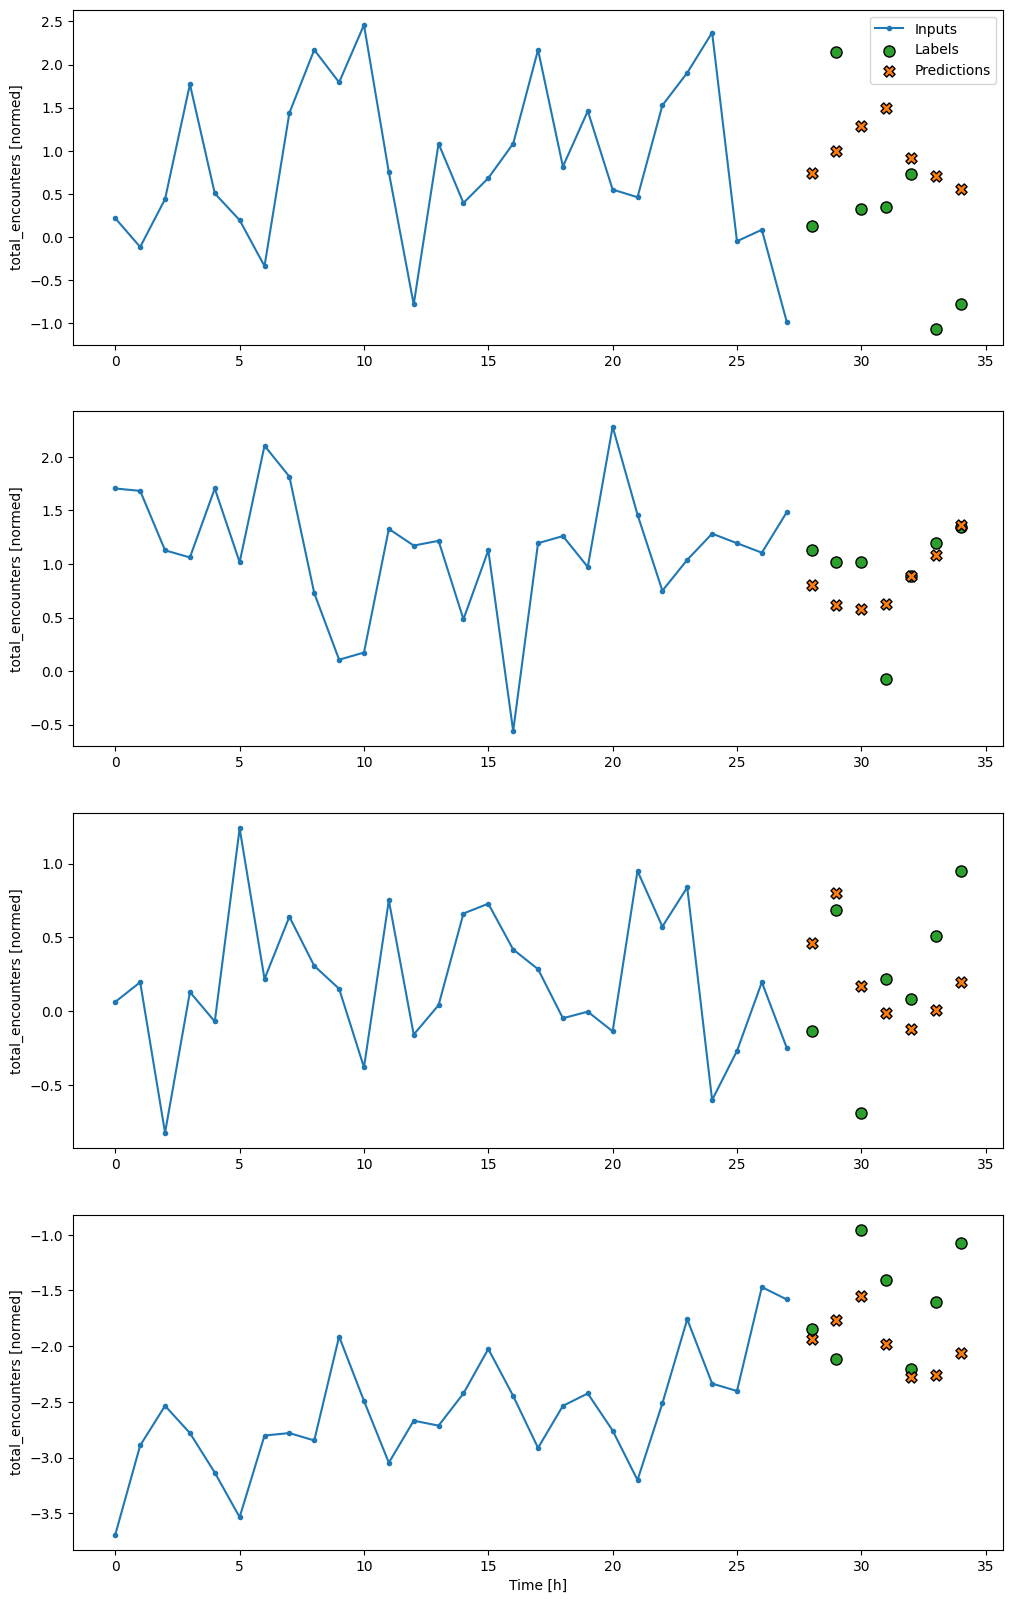

In [69]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=7, strides=1),
    # tf.keras.layers.GlobalAveragePooling1D(),
    # tf.keras.layers.Conv1D(1024, kernel_size=14, strides=7),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(1024, activation='tanh'),
    tf.keras.layers.Dense(7*7),
    tf.keras.layers.Reshape((7,7))

])

history = compile_and_fit(cnn, multi_window, lr=LR)

# IPython.display.clear_output()
multi_val_performance['Conv_7'] = cnn.evaluate(multi_window.val, verbose=0, return_dict=True)
multi_performance['Conv_7'] = cnn.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(cnn)


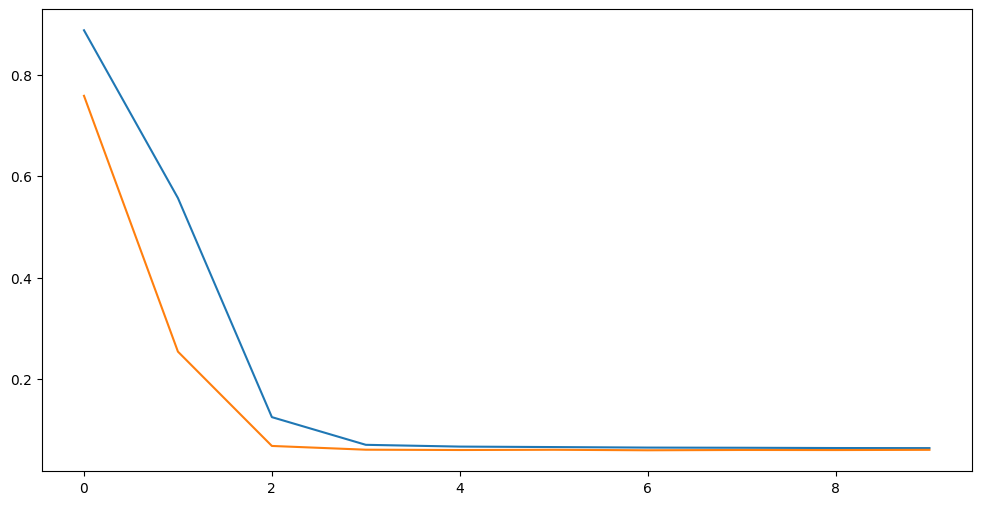

In [70]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']

plt.plot(train_losses)
plt.plot(val_losses)

plt.show()

#### AR-LSTM

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.9855 - mean_absolute_error: 0.8744 - val_loss: 0.9547 - val_mean_absolute_error: 0.8700
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9293 - mean_absolute_error: 0.8492 - val_loss: 0.8938 - val_mean_absolute_error: 0.8327
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8922 - mean_absolute_error: 0.8307 - val_loss: 0.8423 - val_mean_absolute_error: 0.8051
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8049 - mean_absolute_error: 0.7799 - val_loss: 0.6349 - val_mean_absolute_error: 0.6480
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5905 - mean_absolute_error: 0.6077 - val_loss: 0.5088 - val_mean_absolute_error: 0.5722
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4211 - mean_absolute_error: 0.5054 - val_loss: 0.3273 - val_mean_absolute_error: 0.4325
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2600 - mean_absolute_error: 0.3653 - val_los

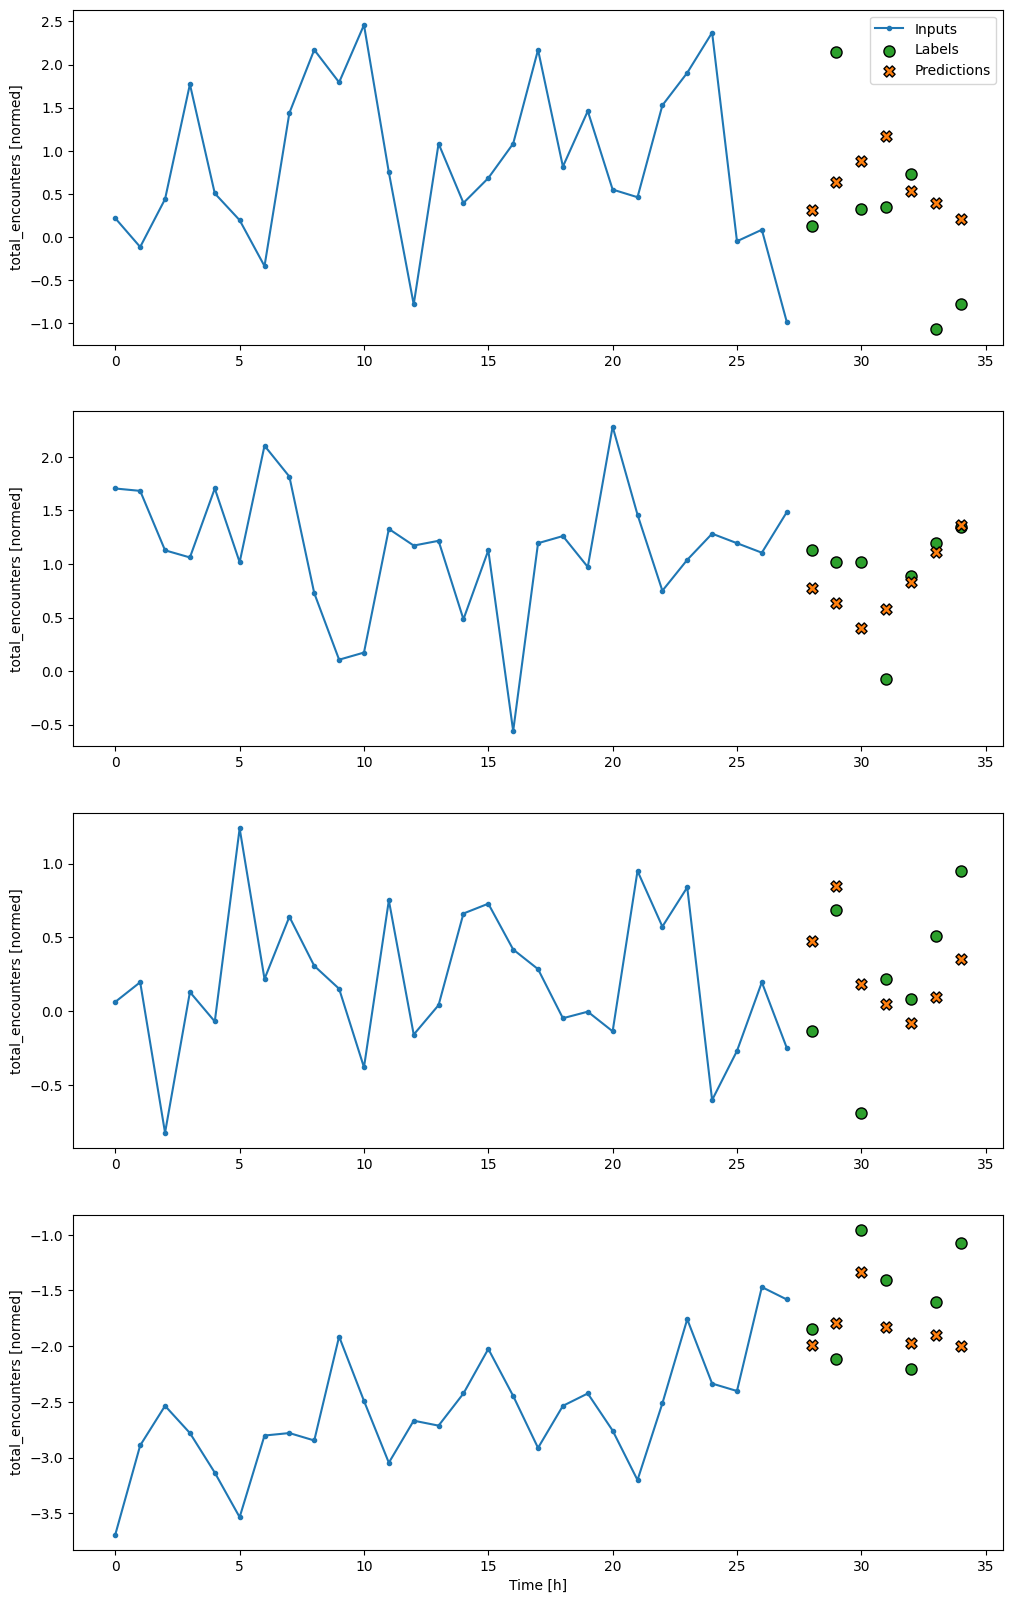

In [ ]:
class FeedBack(tf.keras.Model):
  def __init__(self, units, out_steps):
    super().__init__()
    self.out_steps = out_steps
    self.units = units
    self.lstm_cell = tf.keras.layers.LSTMCell(units, activation='tanh')
    # Also wrap the LSTMCell in an RNN to simplify the `warmup` method.
    self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
    # self.dense1 = tf.keras.Sequential([
    #   tf.keras.layers.Dense(128, activation='relu'),
    #   tf.keras.layers.Dropout(0.2)
    # ])
    # self.dense2 = tf.keras.Sequential([
    #   tf.keras.layers.Dense(64, activation='relu'),
    #   tf.keras.layers.Dropout(0.2)
    # ])
    self.dense3 = tf.keras.layers.Dense(num_features)
  
  def warmup(self, inputs):
    # Encoder
    # inputs.shape => (batch, time, features)
    # x.shape => (batch, lstm_units)
    x, *state = self.lstm_rnn(inputs)

    # predictions.shape => (batch, features)
    # prediction = self.dense1(x)
    # prediction = self.dense2(prediction)
    prediction = self.dense3(x) # change x to prediction if want to uncomment previous
    return prediction, state
  
  def call(self, inputs, training=None):
    # Use a TensorArray to capture dynamically unrolled outputs.
    predictions = []
    # Initialize the LSTM state.
    prediction, state = self.warmup(inputs)

    # Insert the first prediction.
    predictions.append(prediction)

    # Run the rest of the prediction steps.
    # Decoder
    for n in range(1, self.out_steps):
      # Use the last prediction as input.
      x = prediction
      # Execute one lstm step.
      x, state = self.lstm_cell(x, states=state,
                                training=training)
      # Convert the lstm output to a prediction.
      # prediction = self.dense1(x)
      # prediction = self.dense2(prediction)
      prediction = self.dense3(x) # change x to prediction if want to uncomment previous
      # Add the prediction to the output.
      predictions.append(prediction)

    # predictions.shape => (time, batch, features)
    predictions = tf.stack(predictions)
    # predictions.shape => (batch, time, features)
    predictions = tf.transpose(predictions, [1, 0, 2])
    return predictions
  

feedback_model = FeedBack(units=UNITS, out_steps=OUT_STEPS)


history = compile_and_fit(feedback_model, multi_window, patience=2, max_epochs=MAX_EPOCHS, lr=LR)

# IPython.display.clear_output()

multi_val_performance['AR LSTM'] = feedback_model.evaluate(multi_window.val, verbose=0, return_dict=True)
multi_performance['AR LSTM'] = feedback_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(feedback_model)


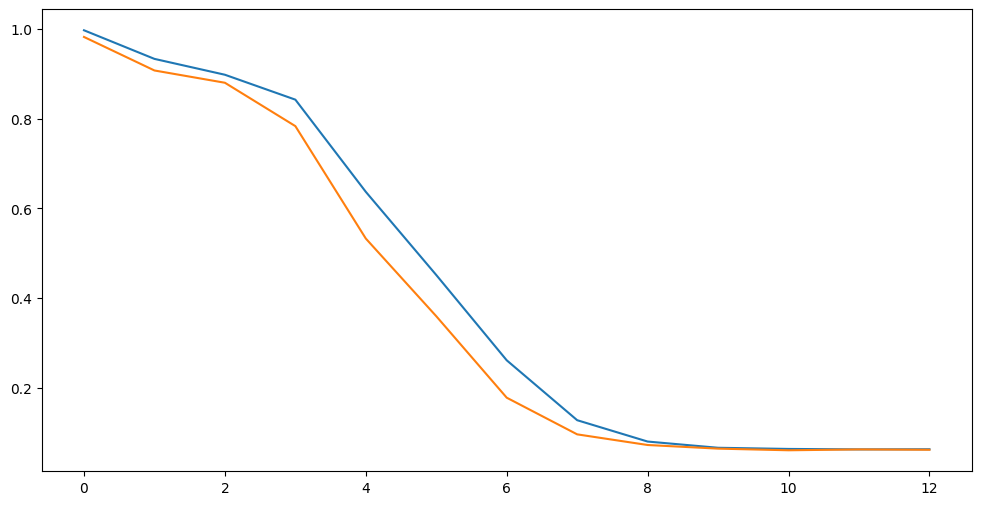

In [20]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']

plt.plot(train_losses)
plt.plot(val_losses)

plt.show()

# Evaluation

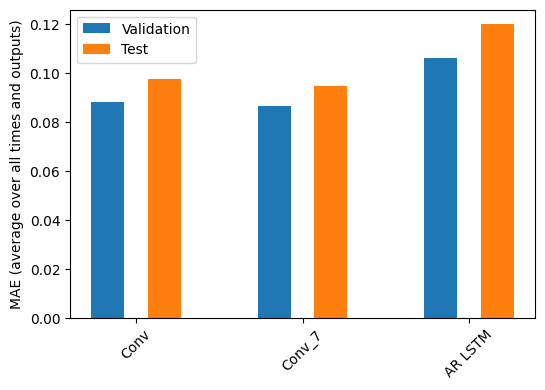

In [71]:
plt.figure(figsize=(6,4))
x = np.arange(len(multi_performance))
width = 0.2

metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in multi_val_performance.values()]
test_mae = [v[metric_name] for v in multi_performance.values()]

plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=list(multi_performance.keys()),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

In [22]:
multi_window.total_window_size

35

# Post processing

Reconcile with the monthly SARIMA model

In [23]:
train_dates = date_time[0:int(n*0.7)]
val_dates = date_time[int(n*0.7):int(n*0.9)]
test_dates = date_time[int(n*0.9):]

In [24]:
# sarima_daily_avgs

df_monthly = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month.csv',
                            parse_dates=['Date'])
filter = df_monthly[['Date', 'total_encounters']]
dictionary = filter.set_index([df_monthly['Date'].dt.month, df_monthly['Date'].dt.year]).drop('Date', axis=1).to_dict()['total_encounters']


In [25]:
import numpy as np
import pandas as pd

def boundary_reconcile(lstm_preds, dates, sarima_forecasts):
    """
    lstm_preds: np.array of 7 predictions
    dates: list of 7 pd.Timestamp objects
    sarima_forecasts: dict {(month, year): total_monthly_forecast}
    """
    reconciled_preds = np.zeros_like(lstm_preds)
    
    # 1. Identify unique months in this 7-day window
    # Example: [(1, 2026), (2, 2026)]
    unique_periods = sorted(list(set((d.month, d.year) for d in dates)))
    
    for month, year in unique_periods:
        # Find indices of the days belonging to this specific month
        mask = np.array([(d.month == month and d.year == year) for d in dates])
        
        # Calculate the SARIMA daily average for THIS specific month/year
        monthly_total = sarima_forecasts[(month, year)]
        days_in_month = pd.Period(f"{year}-{month}").days_in_month
        sarima_daily_avg = monthly_total / days_in_month
        
        # Calculate the LSTM's current daily average for this segment
        lstm_segment_avg = np.mean(lstm_preds[mask])
        
        # Calculate the scaling factor (K) for this month
        # This aligns the LSTM's 'local' level to the SARIMA's 'global' level
        k = sarima_daily_avg / lstm_segment_avg
        
        # Apply the correction only to the days in this month
        reconciled_preds[mask] = lstm_preds[mask] * k
        
    return reconciled_preds

In [26]:
int(test_df.shape[0] / 7)

40

In [27]:
count = 0
for moving in range(int(test_df.shape[0] / 7)):
    count+=1
    test = test_df[7*moving:multi_window.total_window_size+ (7*moving)].to_numpy(dtype=np.float32)
    input =test[:LOOK_BACK]
    label = test[LOOK_BACK:]
    preds = feedback_model(input[None,:,:]).numpy().squeeze(axis=0)
    p = (preds[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]
    l = (label[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]


    d = test_dates[7*moving:multi_window.total_window_size+ (7*moving)][-7:]

    r = boundary_reconcile(p, d, dictionary)

    print(p)
    print(r)
    print(l)
    print('=========================')



[497.43463 468.51328 459.27713 451.7717  457.5423  468.71854 478.9295 ]
[516.58545 486.55063 476.9589  469.16452 475.15726 486.7638  497.36786]
[530. 469. 468. 534. 559. 543. 533.]
[517.4348  491.39862 482.01724 472.98218 477.3748  488.08932 497.3699 ]
[499.5024  474.36853 486.62924 477.50772 481.94235 492.7594  502.12878]
[561. 501. 500. 486. 496. 469. 475.]
[514.0969  485.5276  474.83066 466.63046 471.38962 482.3896  492.3878 ]
[518.6656  489.84238 479.05038 470.7773  475.57877 486.67648 496.76355]
[509. 456. 490. 483. 481. 479. 458.]
[504.9332  475.87476 466.03735 458.30713 463.64877 474.9065  485.24402]
[518.34216 488.51202 478.4134  470.47787 475.9614  487.51807 498.1301 ]
[498. 434. 504. 505. 465. 479. 461.]
[501.40372 472.48703 462.99225 455.32352 460.91714 472.2086  482.3887 ]
[518.02264 488.14752 478.33804 470.41513 476.19415 487.85986 498.37738]
[478. 475. 529. 514. 486. 488. 500.]
[509.03036 481.19363 471.4554  463.16235 468.25107 479.38455 489.10507]
[519.21375 490.82013 48

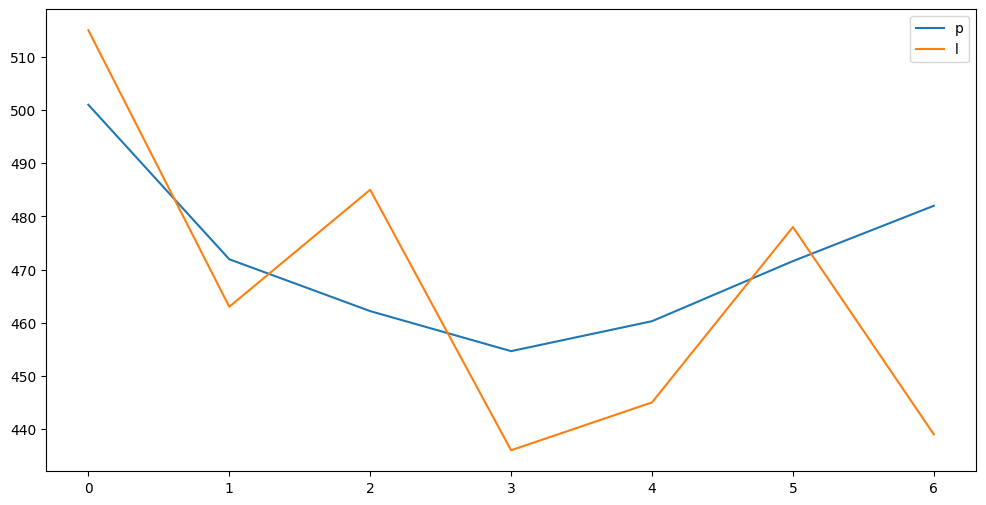

In [28]:
test = test_df[7*7:35+7*7].to_numpy(dtype=np.float32)

input = test[:LOOK_BACK]

label = test[LOOK_BACK:]
preds = feedback_model(input[None,:,:]).numpy().squeeze(axis=0)
p = (preds[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]

l = (label[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]
pd.DataFrame({"p":p, "l":l}).plot()

d = test_dates[7*7:35+7*7][-7:]



In [29]:
print(p)
print(boundary_reconcile(p, d, dictionary))
print(l)

[500.9922  471.92947 462.1767  454.64655 460.28015 471.58282 481.9898 ]
[507.04343 477.6297  467.7591  460.138   465.83966 477.27884 487.81152]
[515. 463. 485. 436. 445. 478. 439.]


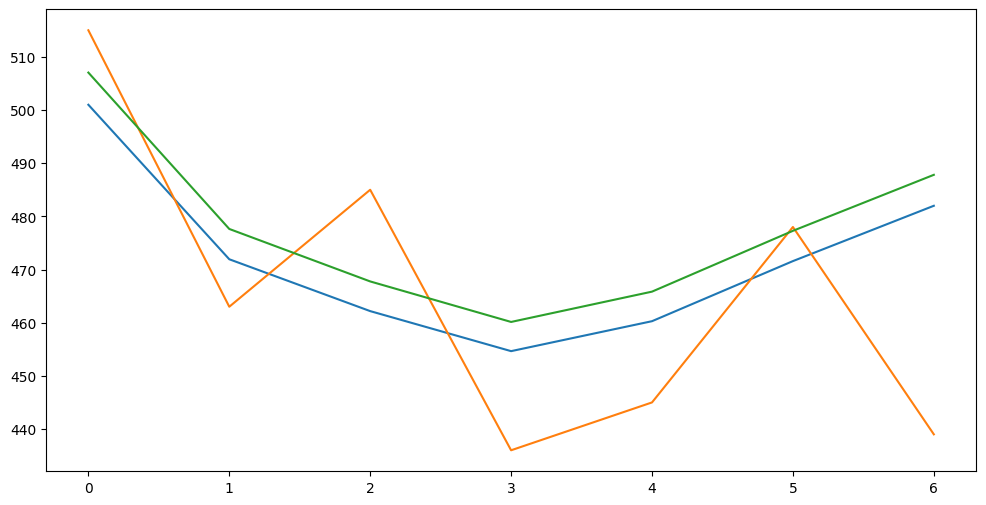

In [30]:
plt.plot(p)
plt.plot(l)
plt.plot(boundary_reconcile(p, d, dictionary))

In [31]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(l, p), mean_absolute_error(l, boundary_reconcile(p, d, dictionary))

(18.44203758239746, 19.19107437133789)